# Creación e implementación de un Data Warehouse usando PostgreSQL y Jupyter con Python

En esta práctica se desarrollará un Data Warehouse de ventas utilizando PostgreSQL como gestor de base de datos y Jupyter Notebook con Python para la carga, transformación, consulta y visualización de datos.

El modelo utilizado será un esquema estrella, compuesto por tablas de dimensión y una tabla de hechos. Las dimensiones almacenarán información descriptiva sobre clientes, productos, regiones y tiempo, mientras que la tabla de hechos almacenará las ventas realizadas.

El proceso incluye la creación de la base de datos, la creación de tablas dimensionales y tabla de hechos, la simulación de datos, generación de archivos CSV, limpieza y normalización de datos con pandas, carga de información a PostgreSQL mediante SQLAlchemy, consultas SQL y generación de gráficas con Matplotlib para analizar indicadores clave como ventas por región, productos más vendidos y ventas por mes.

In [1]:
#Instalación de librerias
!pip install  sqlalchemy psycopg2-binary 

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 20.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 32.0 MB/s  0:00:00

   ------------- -------------------------- 1/3 [greenlet]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 2/3 [sqlalchemy]
   -------------------------- ------------- 

In [3]:
# Importación de librerías para manejo de datos, conexión y gráficas
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

In [10]:
# Datos de conexión a PostgreSQL
usuario = "postgres"
password = "123456"
host = "localhost"
puerto = "5432"
base_datos = "datawarehouse_ventas"

# Creación de la conexión con PostgreSQL
engine = create_engine(
    f"postgresql+psycopg2://{usuario}:{password}@{host}:{puerto}/{base_datos}"
)

print("Conexión creada correctamente")

Conexión creada correctamente


In [11]:
# Prueba de conexión mostrando la versión de PostgreSQL
with engine.connect() as conn:
    resultado = conn.execute(text("SELECT version();"))
    for fila in resultado:
        print(fila)

('PostgreSQL 16.3, compiled by Visual C++ build 1939, 64-bit',)


In [12]:
# Creación de tablas de dimensión y tabla de hechos
with engine.connect() as conn:
    conn.execute(text("""
        DROP TABLE IF EXISTS hecho_ventas;
        DROP TABLE IF EXISTS dim_cliente;
        DROP TABLE IF EXISTS dim_producto;
        DROP TABLE IF EXISTS dim_region;
        DROP TABLE IF EXISTS dim_tiempo;

        CREATE TABLE dim_cliente (
            id_cliente INTEGER PRIMARY KEY,
            nombre_cliente VARCHAR(100),
            genero VARCHAR(20),
            edad INTEGER
        );

        CREATE TABLE dim_producto (
            id_producto INTEGER PRIMARY KEY,
            nombre_producto VARCHAR(100),
            categoria VARCHAR(50),
            precio_unitario NUMERIC(10,2)
        );

        CREATE TABLE dim_region (
            id_region INTEGER PRIMARY KEY,
            region VARCHAR(50),
            ciudad VARCHAR(50)
        );

        CREATE TABLE dim_tiempo (
            id_tiempo INTEGER PRIMARY KEY,
            fecha DATE,
            mes VARCHAR(20),
            anio INTEGER
        );

        CREATE TABLE hecho_ventas (
            id_venta INTEGER PRIMARY KEY,
            id_cliente INTEGER,
            id_producto INTEGER,
            id_region INTEGER,
            id_tiempo INTEGER,
            cantidad INTEGER,
            total_venta NUMERIC(10,2),

            FOREIGN KEY (id_cliente) REFERENCES dim_cliente(id_cliente),
            FOREIGN KEY (id_producto) REFERENCES dim_producto(id_producto),
            FOREIGN KEY (id_region) REFERENCES dim_region(id_region),
            FOREIGN KEY (id_tiempo) REFERENCES dim_tiempo(id_tiempo)
        );
    """))
    conn.commit()

print("Tablas creadas correctamente")

Tablas creadas correctamente


In [13]:
# Creación de datos simulados para clientes
clientes = pd.DataFrame({
    "id_cliente": [1, 2, 3, 4, 5],
    "nombre_cliente": ["Ana López", "Carlos Pérez", "María García", "Luis Torres", "Sofía Hernández"],
    "genero": ["Femenino", "Masculino", "Femenino", "Masculino", "Femenino"],
    "edad": [22, 35, 29, 41, 31]
})

# Creación de datos simulados para productos
productos = pd.DataFrame({
    "id_producto": [1, 2, 3, 4, 5],
    "nombre_producto": ["Laptop", "Mouse", "Teclado", "Monitor", "Impresora"],
    "categoria": ["Computo", "Accesorio", "Accesorio", "Computo", "Oficina"],
    "precio_unitario": [12000, 250, 600, 3500, 2800]
})

# Creación de datos simulados para regiones
regiones = pd.DataFrame({
    "id_region": [1, 2, 3, 4],
    "region": ["Norte", "Sur", "Centro", "Este"],
    "ciudad": ["Monterrey", "Veracruz", "CDMX", "Puebla"]
})

# Creación de datos simulados para tiempo
tiempo = pd.DataFrame({
    "id_tiempo": [1, 2, 3, 4, 5, 6],
    "fecha": ["2026-01-10", "2026-02-15", "2026-03-20", "2026-04-12", "2026-05-18", "2026-06-05"],
    "mes": ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"],
    "anio": [2026, 2026, 2026, 2026, 2026, 2026]
})

# Creación de datos simulados para ventas
ventas = pd.DataFrame({
    "id_venta": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "id_cliente": [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
    "id_producto": [1, 2, 3, 4, 5, 2, 3, 1, 5, 4],
    "id_region": [1, 2, 3, 4, 1, 2, 3, 4, 2, 1],
    "id_tiempo": [1, 2, 3, 4, 5, 6, 1, 2, 3, 4],
    "cantidad": [2, 5, 3, 1, 2, 4, 6, 1, 3, 2]
})

In [14]:
# Cálculo del total de venta usando cantidad y precio unitario
ventas = ventas.merge(productos[["id_producto", "precio_unitario"]], on="id_producto")
ventas["total_venta"] = ventas["cantidad"] * ventas["precio_unitario"]
ventas = ventas.drop(columns=["precio_unitario"])

ventas

,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,total_venta
0,1,1,1,1,1,2,24000
1,2,2,2,2,2,5,1250
2,3,3,3,3,3,3,1800
3,4,4,4,4,4,1,3500
4,5,5,5,1,5,2,5600
5,6,1,2,2,6,4,1000
6,7,2,3,3,1,6,3600
7,8,3,1,4,2,1,12000
8,9,4,5,2,3,3,8400
9,10,5,4,1,4,2,7000


In [15]:
# Exportación de los datos simulados a archivos CSV
clientes.to_csv("clientes.csv", index=False)
productos.to_csv("productos.csv", index=False)
regiones.to_csv("regiones.csv", index=False)
tiempo.to_csv("tiempo.csv", index=False)
ventas.to_csv("ventas.csv", index=False)

print("Archivos CSV creados correctamente")

Archivos CSV creados correctamente


In [16]:
# Importación de archivos CSV con pandas
df_clientes = pd.read_csv("clientes.csv")
df_productos = pd.read_csv("productos.csv")
df_regiones = pd.read_csv("regiones.csv")
df_tiempo = pd.read_csv("tiempo.csv")
df_ventas = pd.read_csv("ventas.csv")

print("CSV importados correctamente")

CSV importados correctamente


In [17]:
# Visualización de la tabla de ventas importada
df_ventas

,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,total_venta
0,1,1,1,1,1,2,24000
1,2,2,2,2,2,5,1250
2,3,3,3,3,3,3,1800
3,4,4,4,4,4,1,3500
4,5,5,5,1,5,2,5600
5,6,1,2,2,6,4,1000
6,7,2,3,3,1,6,3600
7,8,3,1,4,2,1,12000
8,9,4,5,2,3,3,8400
9,10,5,4,1,4,2,7000


In [18]:
# Revisión de valores nulos en cada conjunto de datos
print("Nulos en clientes:")
print(df_clientes.isnull().sum())

print("\nNulos en productos:")
print(df_productos.isnull().sum())

print("\nNulos en regiones:")
print(df_regiones.isnull().sum())

print("\nNulos en tiempo:")
print(df_tiempo.isnull().sum())

print("\nNulos en ventas:")
print(df_ventas.isnull().sum())

Nulos en clientes:
id_cliente        0
nombre_cliente    0
genero            0
edad              0
dtype: int64

Nulos en productos:
id_producto        0
nombre_producto    0
categoria          0
precio_unitario    0
dtype: int64

Nulos en regiones:
id_region    0
region       0
ciudad       0
dtype: int64

Nulos en tiempo:
id_tiempo    0
fecha        0
mes          0
anio         0
dtype: int64

Nulos en ventas:
id_venta       0
id_cliente     0
id_producto    0
id_region      0
id_tiempo      0
cantidad       0
total_venta    0
dtype: int64


In [19]:
# Eliminación de duplicados y conversión de fecha
df_clientes = df_clientes.drop_duplicates()
df_productos = df_productos.drop_duplicates()
df_regiones = df_regiones.drop_duplicates()
df_tiempo = df_tiempo.drop_duplicates()
df_ventas = df_ventas.drop_duplicates()

df_tiempo["fecha"] = pd.to_datetime(df_tiempo["fecha"])

print("Datos normalizados correctamente")

Datos normalizados correctamente


In [20]:
# Revisión de columnas y tipos de datos
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id_venta     10 non-null     int64
 1   id_cliente   10 non-null     int64
 2   id_producto  10 non-null     int64
 3   id_region    10 non-null     int64
 4   id_tiempo    10 non-null     int64
 5   cantidad     10 non-null     int64
 6   total_venta  10 non-null     int64
dtypes: int64(7)
memory usage: 692.0 bytes


In [21]:
# Limpieza de tablas para evitar datos duplicados
with engine.connect() as conn:
    conn.execute(text("DELETE FROM hecho_ventas;"))
    conn.execute(text("DELETE FROM dim_cliente;"))
    conn.execute(text("DELETE FROM dim_producto;"))
    conn.execute(text("DELETE FROM dim_region;"))
    conn.execute(text("DELETE FROM dim_tiempo;"))
    conn.commit()

print("Tablas limpiadas correctamente")

Tablas limpiadas correctamente


In [22]:
# Carga de DataFrames a tablas del Data Warehouse en PostgreSQL
df_clientes.to_sql("dim_cliente", engine, if_exists="append", index=False)
df_productos.to_sql("dim_producto", engine, if_exists="append", index=False)
df_regiones.to_sql("dim_region", engine, if_exists="append", index=False)
df_tiempo.to_sql("dim_tiempo", engine, if_exists="append", index=False)
df_ventas.to_sql("hecho_ventas", engine, if_exists="append", index=False)

print("Datos cargados correctamente al Data Warehouse")

Datos cargados correctamente al Data Warehouse


In [23]:
# Consulta de datos cargados en la tabla de hechos
pd.read_sql("SELECT * FROM hecho_ventas;", engine)

,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,total_venta
0,1,1,1,1,1,2,24000.0
1,2,2,2,2,2,5,1250.0
2,3,3,3,3,3,3,1800.0
3,4,4,4,4,4,1,3500.0
4,5,5,5,1,5,2,5600.0
5,6,1,2,2,6,4,1000.0
6,7,2,3,3,1,6,3600.0
7,8,3,1,4,2,1,12000.0
8,9,4,5,2,3,3,8400.0
9,10,5,4,1,4,2,7000.0


In [24]:
# Consulta general uniendo hechos con dimensiones
reporte_general = pd.read_sql("""
    SELECT 
        v.id_venta,
        c.nombre_cliente,
        p.nombre_producto,
        p.categoria,
        r.region,
        r.ciudad,
        t.fecha,
        t.mes,
        t.anio,
        v.cantidad,
        v.total_venta
    FROM hecho_ventas v
    INNER JOIN dim_cliente c ON v.id_cliente = c.id_cliente
    INNER JOIN dim_producto p ON v.id_producto = p.id_producto
    INNER JOIN dim_region r ON v.id_region = r.id_region
    INNER JOIN dim_tiempo t ON v.id_tiempo = t.id_tiempo
    ORDER BY v.id_venta;
""", engine)

reporte_general

,id_venta,nombre_cliente,nombre_producto,categoria,region,ciudad,fecha,mes,anio,cantidad,total_venta
0,1,Ana López,Laptop,Computo,Norte,Monterrey,2026-01-10,Enero,2026,2,24000.0
1,2,Carlos Pérez,Mouse,Accesorio,Sur,Veracruz,2026-02-15,Febrero,2026,5,1250.0
2,3,María García,Teclado,Accesorio,Centro,CDMX,2026-03-20,Marzo,2026,3,1800.0
3,4,Luis Torres,Monitor,Computo,Este,Puebla,2026-04-12,Abril,2026,1,3500.0
4,5,Sofía Hernández,Impresora,Oficina,Norte,Monterrey,2026-05-18,Mayo,2026,2,5600.0
5,6,Ana López,Mouse,Accesorio,Sur,Veracruz,2026-06-05,Junio,2026,4,1000.0
6,7,Carlos Pérez,Teclado,Accesorio,Centro,CDMX,2026-01-10,Enero,2026,6,3600.0
7,8,María García,Laptop,Computo,Este,Puebla,2026-02-15,Febrero,2026,1,12000.0
8,9,Luis Torres,Impresora,Oficina,Sur,Veracruz,2026-03-20,Marzo,2026,3,8400.0
9,10,Sofía Hernández,Monitor,Computo,Norte,Monterrey,2026-04-12,Abril,2026,2,7000.0


#Analisis y visualizacion

In [25]:
# Consulta para obtener ventas agrupadas por región
ventas_region = pd.read_sql("""
    SELECT 
        r.region,
        SUM(v.total_venta) AS total_ventas
    FROM hecho_ventas v
    INNER JOIN dim_region r ON v.id_region = r.id_region
    GROUP BY r.region
    ORDER BY total_ventas DESC;
""", engine)

ventas_region

,region,total_ventas
0,Norte,36600.0
1,Este,15500.0
2,Sur,10650.0
3,Centro,5400.0


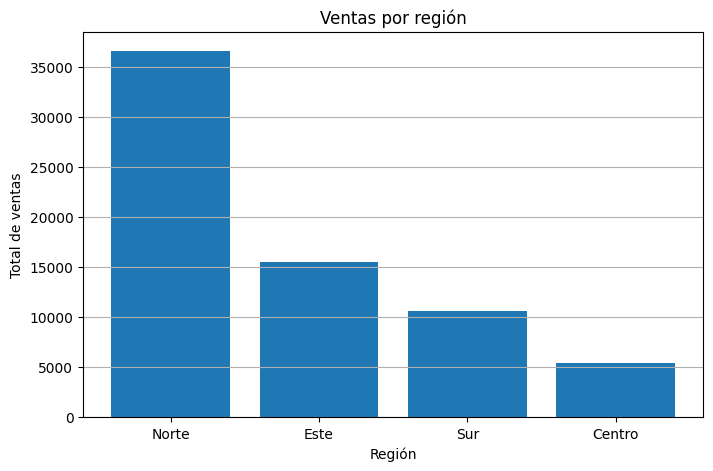

In [26]:
# Gráfica de barras para comparar ventas por región
plt.figure(figsize=(8,5))
plt.bar(ventas_region["region"], ventas_region["total_ventas"])
plt.title("Ventas por región")
plt.xlabel("Región")
plt.ylabel("Total de ventas")
plt.grid(axis="y")
plt.show()

In [27]:
# Consulta para obtener productos más vendidos
productos_vendidos = pd.read_sql("""
    SELECT 
        p.nombre_producto,
        SUM(v.cantidad) AS cantidad_vendida
    FROM hecho_ventas v
    INNER JOIN dim_producto p ON v.id_producto = p.id_producto
    GROUP BY p.nombre_producto
    ORDER BY cantidad_vendida DESC;
""", engine)

productos_vendidos

,nombre_producto,cantidad_vendida
0,Teclado,9
1,Mouse,9
2,Impresora,5
3,Monitor,3
4,Laptop,3


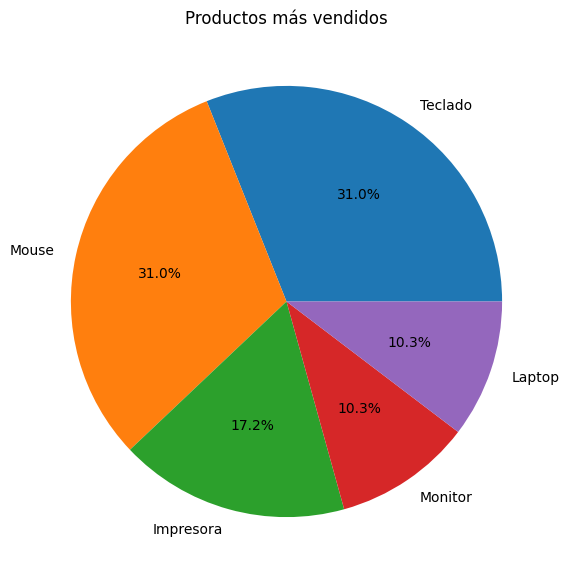

In [28]:
# Gráfica de pastel para mostrar proporción de productos vendidos
plt.figure(figsize=(7,7))
plt.pie(
    productos_vendidos["cantidad_vendida"],
    labels=productos_vendidos["nombre_producto"],
    autopct="%1.1f%%"
)
plt.title("Productos más vendidos")
plt.show()

In [29]:
# Consulta para obtener ventas agrupadas por mes
ventas_mes = pd.read_sql("""
    SELECT 
        t.id_tiempo,
        t.mes,
        SUM(v.total_venta) AS total_ventas
    FROM hecho_ventas v
    INNER JOIN dim_tiempo t ON v.id_tiempo = t.id_tiempo
    GROUP BY t.id_tiempo, t.mes
    ORDER BY t.id_tiempo;
""", engine)

ventas_mes

,id_tiempo,mes,total_ventas
0,1,Enero,27600.0
1,2,Febrero,13250.0
2,3,Marzo,10200.0
3,4,Abril,10500.0
4,5,Mayo,5600.0
5,6,Junio,1000.0


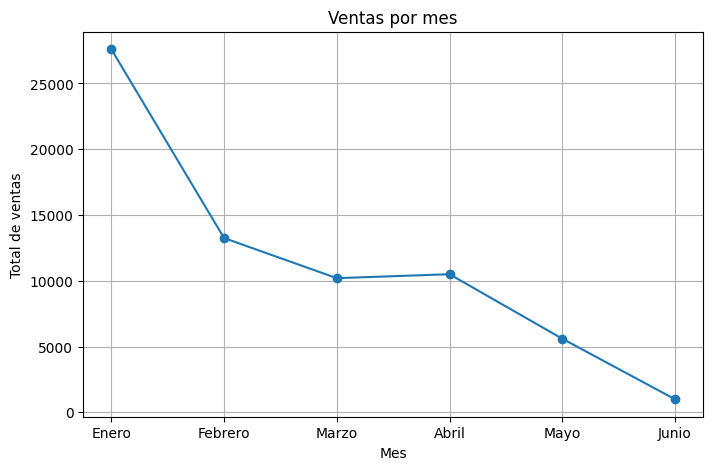

In [30]:
# Gráfica de líneas para observar ventas por mes
plt.figure(figsize=(8,5))
plt.plot(ventas_mes["mes"], ventas_mes["total_ventas"], marker="o")
plt.title("Ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Total de ventas")
plt.grid()
plt.show()